<a href="https://www.kaggle.com/code/sonawanelalitsunil/workplace-burnout-mental-health-ml-100?scriptVersionId=248893206" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/mental-health-and-burnout-in-the-workplace/mental_health_workplace_survey.csv


## Title: 
Workplace Burnout & Mental Health

##  Description:
This topic explores the growing concern of mental health challenges and burnout in today's workplace. It covers the psychological and physical effects of prolonged stress, high workload, lack of support, and poor work-life balance. The discussion highlights key warning signs of burnout, such as emotional exhaustion, reduced performance, and detachment from work. It also examines the responsibility of employers in creating a mentally healthy environment through policies, open communication, flexible work arrangements, and mental health support systems. The goal is to raise awareness and promote actionable strategies for both individuals and organizations to foster well-being and prevent burnout.

## Import dataset

In [2]:
df = pd.read_csv('/kaggle/input/mental-health-and-burnout-in-the-workplace/mental_health_workplace_survey.csv')

In [3]:
df.head()

,EmployeeID,Age,Gender,Country,JobRole,Department,YearsAtCompany,WorkHoursPerWeek,RemoteWork,BurnoutLevel,...,CommuteTime,HasMentalHealthSupport,ManagerSupportScore,HasTherapyAccess,MentalHealthDaysOff,SalaryRange,WorkLifeBalanceScore,TeamSize,CareerGrowthScore,BurnoutRisk
0,1001,50,Male,UK,Sales Associate,HR,14,47,No,3.37,...,117,No,3.15,Yes,8,40K-60K,8.82,6,9.20,0
1,1002,36,Male,Germany,Software Engineer,IT,1,59,Hybrid,7.39,...,8,Yes,4.40,Yes,4,80K-100K,2.80,45,8.46,1
2,1003,29,Non-binary,India,IT Admin,IT,13,59,Hybrid,7.10,...,75,No,3.63,No,6,80K-100K,7.28,7,7.96,1
3,1004,42,Male,Australia,HR Specialist,IT,15,31,Yes,4.18,...,43,Yes,4.50,Yes,9,60K-80K,1.31,11,8.90,0
4,1005,40,Male,Brazil,Customer Support,Support,6,34,Yes,8.28,...,58,Yes,5.51,Yes,6,<40K,1.17,18,8.88,1


In [4]:
df.tail()

,EmployeeID,Age,Gender,Country,JobRole,Department,YearsAtCompany,WorkHoursPerWeek,RemoteWork,BurnoutLevel,...,CommuteTime,HasMentalHealthSupport,ManagerSupportScore,HasTherapyAccess,MentalHealthDaysOff,SalaryRange,WorkLifeBalanceScore,TeamSize,CareerGrowthScore,BurnoutRisk
2995,3996,28,Female,Brazil,Marketing Manager,Sales,18,46,No,2.86,...,4,Yes,6.97,No,1,80K-100K,7.71,21,7.70,0
2996,3997,24,Male,Brazil,Customer Support,Marketing,14,31,No,2.43,...,1,Yes,5.58,Yes,0,60K-80K,3.76,2,2.59,0
2997,3998,22,Female,Canada,Marketing Manager,Marketing,0,38,No,6.87,...,25,No,3.81,No,0,40K-60K,3.03,2,6.95,0
2998,3999,57,Non-binary,Australia,Data Scientist,HR,2,41,No,3.62,...,24,No,9.72,No,3,100K+,6.02,37,9.06,0
2999,4000,46,Non-binary,India,Software Engineer,IT,17,48,No,9.77,...,49,No,8.21,No,7,60K-80K,7.89,37,1.09,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   EmployeeID              3000 non-null   int64  
 1   Age                     3000 non-null   int64  
 2   Gender                  3000 non-null   object 
 3   Country                 3000 non-null   object 
 4   JobRole                 3000 non-null   object 
 5   Department              3000 non-null   object 
 6   YearsAtCompany          3000 non-null   int64  
 7   WorkHoursPerWeek        3000 non-null   int64  
 8   RemoteWork              3000 non-null   object 
 9   BurnoutLevel            3000 non-null   float64
 10  JobSatisfaction         3000 non-null   float64
 11  StressLevel             3000 non-null   float64
 12  ProductivityScore       3000 non-null   float64
 13  SleepHours              3000 non-null   float64
 14  PhysicalActivityHrs     3000 non-null   

In [6]:
df.describe()

,EmployeeID,Age,YearsAtCompany,WorkHoursPerWeek,BurnoutLevel,JobSatisfaction,StressLevel,ProductivityScore,SleepHours,PhysicalActivityHrs,CommuteTime,ManagerSupportScore,MentalHealthDaysOff,WorkLifeBalanceScore,TeamSize,CareerGrowthScore,BurnoutRisk
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.00000,3000.00000,3000.00000,3000.000000,3000.000000,3000.000000,3000.00000,3000.000000,3000.000000,3000.00000,3000.000000,3000.000000
mean,2500.500000,40.805667,10.099333,44.504000,5.509137,5.43750,5.51535,5.51956,6.539000,5.030400,59.227000,5.44254,4.544667,5.450950,25.20100,5.520680,0.326667
std,866.169729,11.011705,6.035032,8.491526,2.574072,2.59443,2.60361,2.60761,1.441876,2.861026,34.809779,2.59740,2.854129,2.602379,14.08645,2.566861,0.469072
min,1001.000000,22.000000,0.000000,30.000000,1.000000,1.00000,1.00000,1.00000,4.000000,0.000000,0.000000,1.00000,0.000000,1.000000,1.00000,1.000000,0.000000
25%,1750.750000,31.000000,5.000000,37.000000,3.300000,3.18000,3.26000,3.28000,5.300000,2.600000,29.000000,3.16000,2.000000,3.160000,13.00000,3.300000,0.000000
50%,2500.500000,41.000000,10.000000,45.000000,5.480000,5.43000,5.49500,5.49000,6.600000,5.000000,59.000000,5.44000,5.000000,5.425000,25.00000,5.580000,0.000000
75%,3250.250000,50.000000,15.000000,52.000000,7.640000,7.68000,7.82250,7.80250,7.800000,7.500000,90.000000,7.69000,7.000000,7.730000,37.00000,7.642500,1.000000
max,4000.000000,59.000000,20.000000,59.000000,10.000000,10.00000,10.00000,10.00000,9.000000,10.000000,119.000000,9.99000,9.000000,10.000000,49.00000,9.990000,1.000000


In [7]:
df.isnull().sum()

EmployeeID                0
Age                       0
Gender                    0
Country                   0
JobRole                   0
Department                0
YearsAtCompany            0
WorkHoursPerWeek          0
RemoteWork                0
BurnoutLevel              0
JobSatisfaction           0
StressLevel               0
ProductivityScore         0
SleepHours                0
PhysicalActivityHrs       0
CommuteTime               0
HasMentalHealthSupport    0
ManagerSupportScore       0
HasTherapyAccess          0
MentalHealthDaysOff       0
SalaryRange               0
WorkLifeBalanceScore      0
TeamSize                  0
CareerGrowthScore         0
BurnoutRisk               0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df.shape

(3000, 25)

In [10]:
df.dtypes

EmployeeID                  int64
Age                         int64
Gender                     object
Country                    object
JobRole                    object
Department                 object
YearsAtCompany              int64
WorkHoursPerWeek            int64
RemoteWork                 object
BurnoutLevel              float64
JobSatisfaction           float64
StressLevel               float64
ProductivityScore         float64
SleepHours                float64
PhysicalActivityHrs       float64
CommuteTime                 int64
HasMentalHealthSupport     object
ManagerSupportScore       float64
HasTherapyAccess           object
MentalHealthDaysOff         int64
SalaryRange                object
WorkLifeBalanceScore      float64
TeamSize                    int64
CareerGrowthScore         float64
BurnoutRisk                 int64
dtype: object

In [11]:
df.columns

Index(['EmployeeID', 'Age', 'Gender', 'Country', 'JobRole', 'Department',
       'YearsAtCompany', 'WorkHoursPerWeek', 'RemoteWork', 'BurnoutLevel',
       'JobSatisfaction', 'StressLevel', 'ProductivityScore', 'SleepHours',
       'PhysicalActivityHrs', 'CommuteTime', 'HasMentalHealthSupport',
       'ManagerSupportScore', 'HasTherapyAccess', 'MentalHealthDaysOff',
       'SalaryRange', 'WorkLifeBalanceScore', 'TeamSize', 'CareerGrowthScore',
       'BurnoutRisk'],
      dtype='object')

## Data visualizations

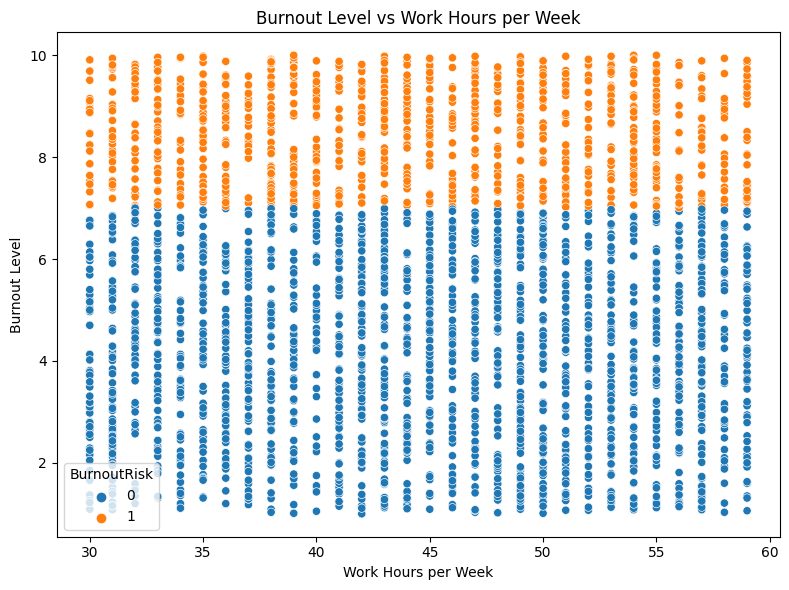

In [12]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='WorkHoursPerWeek', y='BurnoutLevel', hue='BurnoutRisk')
plt.title("Burnout Level vs Work Hours per Week")
plt.xlabel("Work Hours per Week")
plt.ylabel("Burnout Level")
plt.tight_layout()
plt.show()


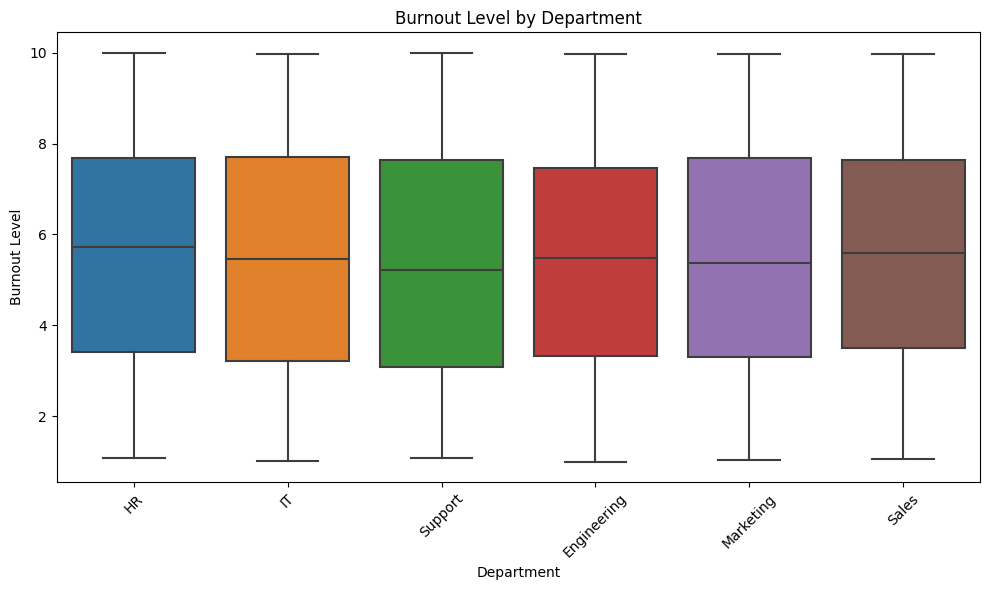

In [13]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Department', y='BurnoutLevel')
plt.title("Burnout Level by Department")
plt.xlabel("Department")
plt.ylabel("Burnout Level")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


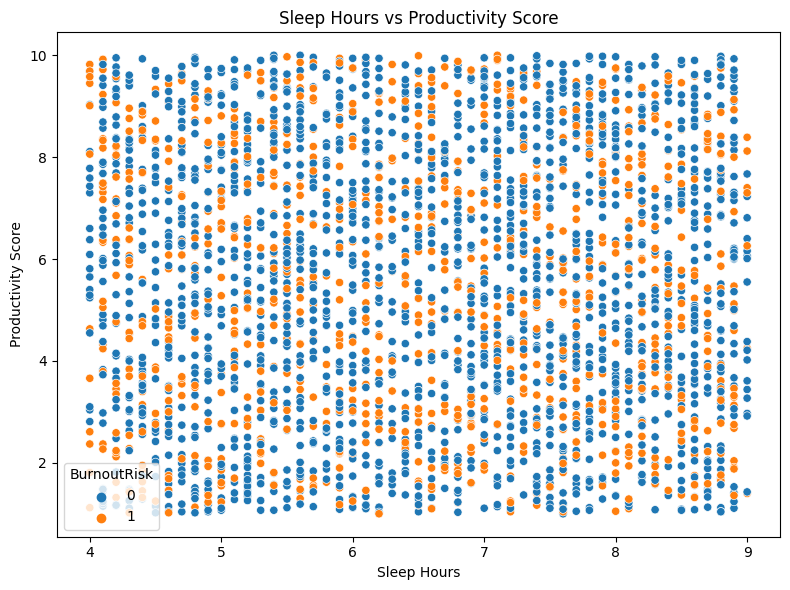

In [14]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='SleepHours', y='ProductivityScore', hue='BurnoutRisk')
plt.title("Sleep Hours vs Productivity Score")
plt.xlabel("Sleep Hours")
plt.ylabel("Productivity Score")
plt.tight_layout()
plt.show()


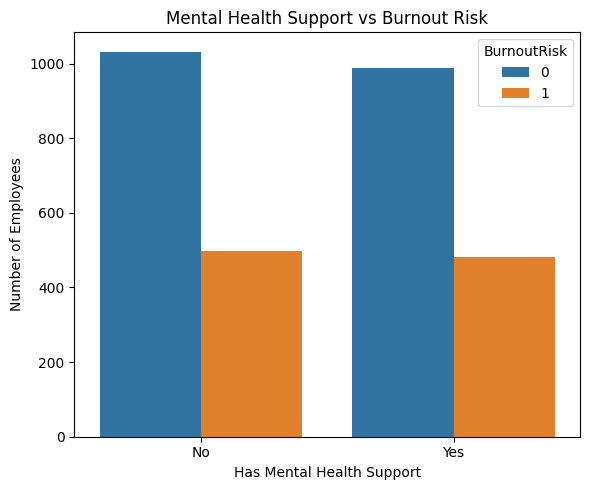

In [15]:
plt.figure(figsize=(6, 5))
sns.countplot(data=df, x='HasMentalHealthSupport', hue='BurnoutRisk')
plt.title("Mental Health Support vs Burnout Risk")
plt.xlabel("Has Mental Health Support")
plt.ylabel("Number of Employees")
plt.tight_layout()
plt.show()


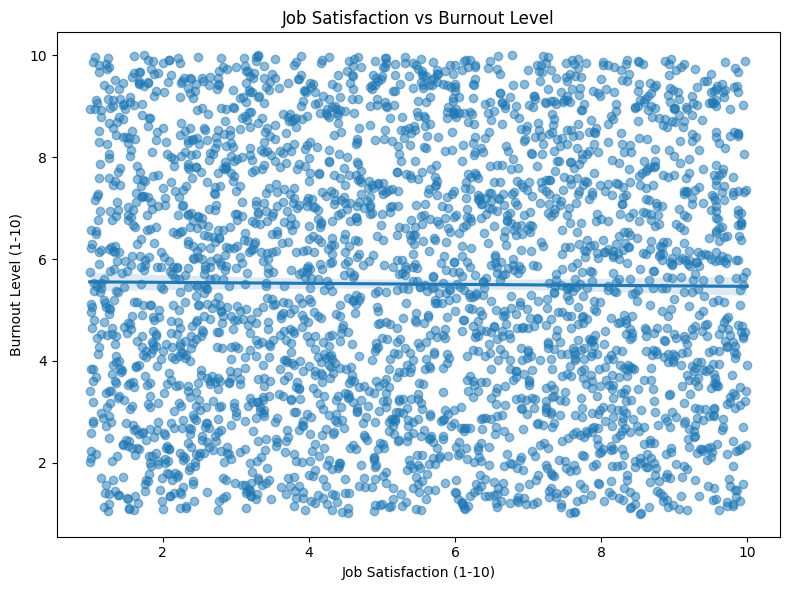

In [16]:
plt.figure(figsize=(8, 6))
sns.regplot(data=df, x='JobSatisfaction', y='BurnoutLevel', scatter_kws={"alpha":0.5})
plt.title("Job Satisfaction vs Burnout Level")
plt.xlabel("Job Satisfaction (1-10)")
plt.ylabel("Burnout Level (1-10)")
plt.tight_layout()
plt.show()


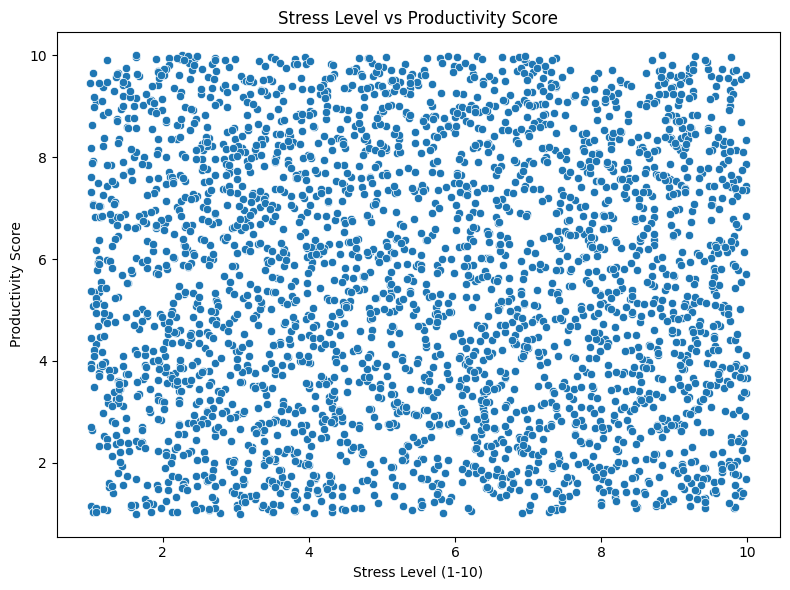

In [17]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='StressLevel', y='ProductivityScore')
plt.title("Stress Level vs Productivity Score")
plt.xlabel("Stress Level (1-10)")
plt.ylabel("Productivity Score")
plt.tight_layout()
plt.show()


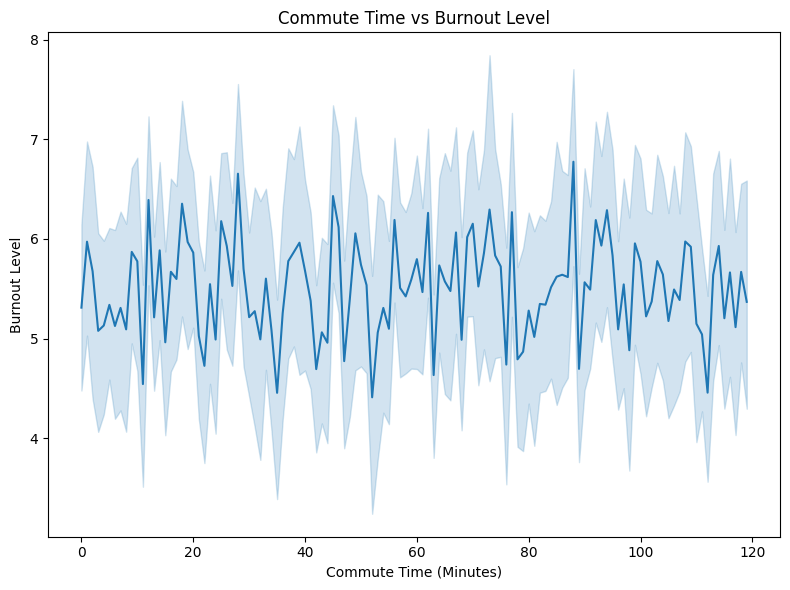

In [18]:
plt.figure(figsize=(8, 6))
sns.lineplot(data=df, x='CommuteTime', y='BurnoutLevel')
plt.title("Commute Time vs Burnout Level")
plt.xlabel("Commute Time (Minutes)")
plt.ylabel("Burnout Level")
plt.tight_layout()
plt.show()


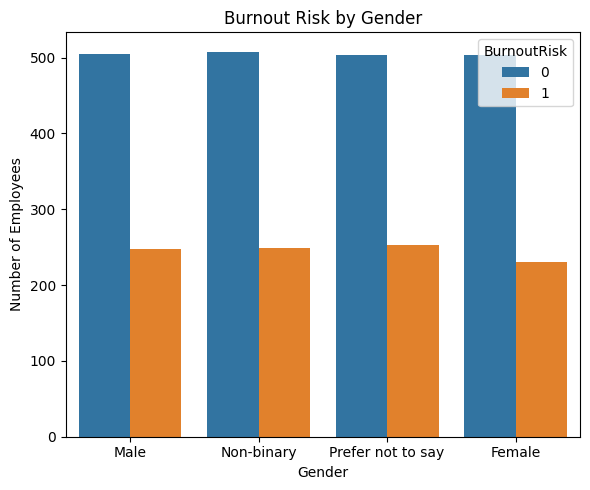

In [19]:
plt.figure(figsize=(6, 5))
sns.countplot(data=df, x='Gender', hue='BurnoutRisk')
plt.title("Burnout Risk by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Employees")
plt.tight_layout()
plt.show()


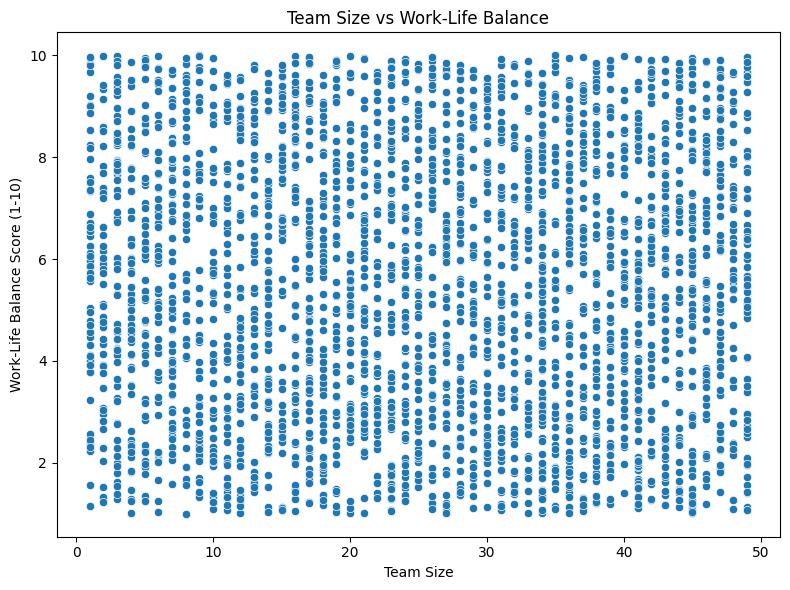

In [20]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='TeamSize', y='WorkLifeBalanceScore')
plt.title("Team Size vs Work-Life Balance")
plt.xlabel("Team Size")
plt.ylabel("Work-Life Balance Score (1-10)")
plt.tight_layout()
plt.show()


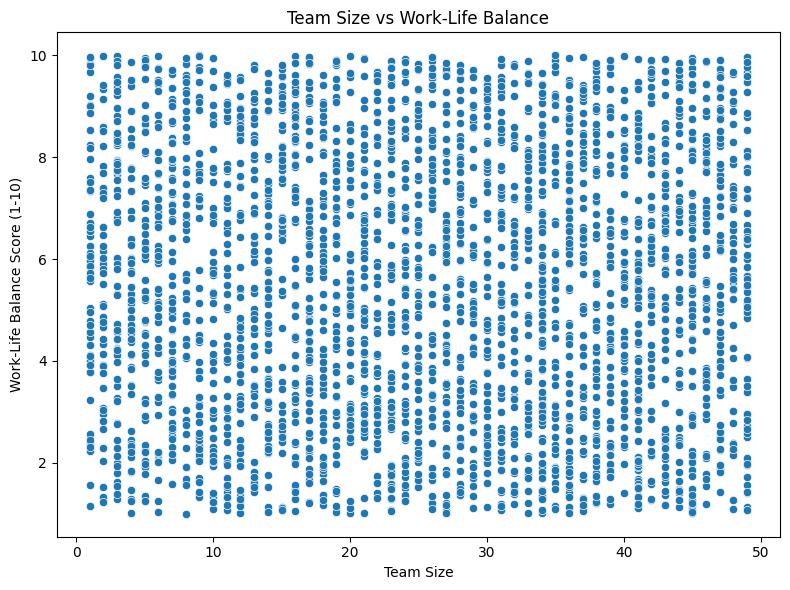

In [21]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='TeamSize', y='WorkLifeBalanceScore')
plt.title("Team Size vs Work-Life Balance")
plt.xlabel("Team Size")
plt.ylabel("Work-Life Balance Score (1-10)")
plt.tight_layout()
plt.show()


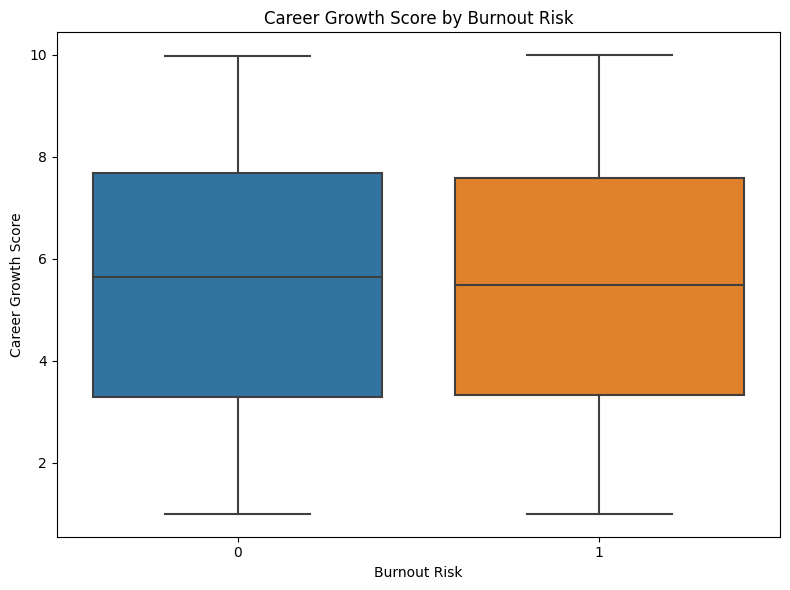

In [22]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='BurnoutRisk', y='CareerGrowthScore')
plt.title("Career Growth Score by Burnout Risk")
plt.xlabel("Burnout Risk")
plt.ylabel("Career Growth Score")
plt.tight_layout()
plt.show()


## Predictive modeling

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

In [24]:
categorical_cols = df.select_dtypes(include=['object', 'bool']).columns

le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col].astype(str))


In [25]:
# Assuming "BurnoutRisk" is the target column
X = df.drop("BurnoutRisk", axis=1)
y = df["BurnoutRisk"]


In [26]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [27]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [28]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(),
    "Decision Tree": DecisionTreeClassifier(),
    "Naive Bayes": GaussianNB(),
    "K-Nearest Neighbors": KNeighborsClassifier()
}

# Train and evaluate
for name, model in models.items():
    print(f"\n🔍 Training: {name}")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print("✅ Accuracy:", accuracy_score(y_test, y_pred))
    print("📊 Classification Report:\n", classification_report(y_test, y_pred))
    print("🧩 Confusion Matrix:\n", confusion_matrix(y_test, y_pred))



🔍 Training: Logistic Regression
✅ Accuracy: 0.995
📊 Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      1.00       399
           1       0.99      1.00      0.99       201

    accuracy                           0.99       600
   macro avg       0.99      1.00      0.99       600
weighted avg       1.00      0.99      1.00       600

🧩 Confusion Matrix:
 [[396   3]
 [  0 201]]

🔍 Training: Random Forest
✅ Accuracy: 1.0
📊 Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       399
           1       1.00      1.00      1.00       201

    accuracy                           1.00       600
   macro avg       1.00      1.00      1.00       600
weighted avg       1.00      1.00      1.00       600

🧩 Confusion Matrix:
 [[399   0]
 [  0 201]]

🔍 Training: SVM
✅ Accuracy: 0.9533333333333334
📊 Classification Report:
               precision    recall  f1-

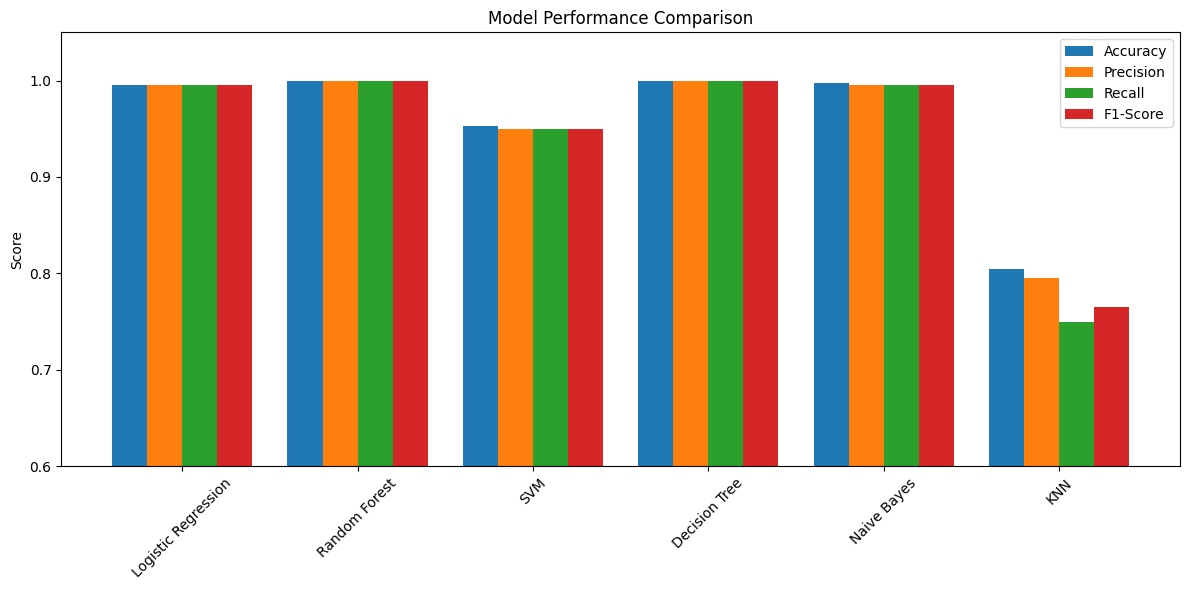

In [29]:
metrics_data = {
    'Model': [
        'Logistic Regression', 'Random Forest', 'SVM',
        'Decision Tree', 'Naive Bayes', 'KNN'
    ],
    'Accuracy': [
        0.995, 1.0, 0.953, 1.0, 0.997, 0.805
    ],
    'Precision': [
        0.995, 1.0, 0.95, 1.0, 0.995, 0.795
    ],
    'Recall': [
        0.995, 1.0, 0.95, 1.0, 0.995, 0.75
    ],
    'F1-Score': [
        0.995, 1.0, 0.95, 1.0, 0.995, 0.765
    ]
}

df_metrics = pd.DataFrame(metrics_data)

# Set figure size and bar width
plt.figure(figsize=(12, 6))
bar_width = 0.2
x = range(len(df_metrics))

# Plot each metric
plt.bar([p - 1.5 * bar_width for p in x], df_metrics['Accuracy'], width=bar_width, label='Accuracy')
plt.bar([p - 0.5 * bar_width for p in x], df_metrics['Precision'], width=bar_width, label='Precision')
plt.bar([p + 0.5 * bar_width for p in x], df_metrics['Recall'], width=bar_width, label='Recall')
plt.bar([p + 1.5 * bar_width for p in x], df_metrics['F1-Score'], width=bar_width, label='F1-Score')

# Customize chart
plt.xticks(x, df_metrics['Model'], rotation=45)
plt.ylim(0.6, 1.05)
plt.ylabel("Score")
plt.title("Model Performance Comparison")
plt.legend()
plt.tight_layout()
plt.show()

## Thank you pls upvote!!!